# Financial News Intelligence
Dark-terminal dashboard exploring topic dynamics, sentiment and embedding structure on a financial news corpus.

In [1]:
# SETUP · imports, theme, paths
from pathlib import Path
import warnings, numpy as np, pandas as pd, polars as pl
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from IPython.display import display
warnings.filterwarnings("ignore")

BG, SURFACE, BORDER = "#020817", "#0f172a", "#1e293b"
ACCENT = ["#60a5fa","#34d399","#f87171","#a78bfa","#fb923c",
          "#facc15","#22d3ee","#f472b6","#fde68a","#4ade80",
          "#f97316","#38bdf8","#c084fc"]
PHASE_COLORS = {"rising":"#34d399","peak":"#f59e0b","fading":"#f87171","dormant":"#64748b"}
plt.rcParams.update({"figure.facecolor": BG, "axes.facecolor": SURFACE,
                     "axes.edgecolor": BORDER, "text.color": "#94a3b8",
                     "axes.labelcolor": "#64748b", "xtick.color": "#334155",
                     "ytick.color": "#334155", "grid.color": BORDER,
                     "font.family": "monospace", "axes.titlecolor": "#e2e8f0",
                     "axes.titleweight": "bold", "legend.facecolor": SURFACE,
                     "legend.edgecolor": BORDER, "savefig.facecolor": BG})

ROOT = Path("..")
DATA = ROOT / "data" / "Stock_news"
FIG  = Path("figures"); FIG.mkdir(exist_ok=True)

SAMPLE_N = 20_000            # keep runs cheap; set to None for the full corpus
RNG = np.random.default_rng(42)

def savefig(fig, n):
    fig.savefig(FIG / f"section_{n}.png", dpi=150, bbox_inches="tight", facecolor=BG)

## Load · Polars → Pandas
Read the three parquet files with polars, sample, join on `id`, and normalise columns to the
spec schema: `article_id / headline / body / published_date / source / topic_* / finbert_score / emb_*`.

In [2]:
# LOAD · polars lazy scans, sample on id, join, rename to spec
articles_cols = ["id","Article_title","Article","Publisher","Stock_symbol","date_parsed"]
lf_art   = pl.scan_parquet(DATA / "subset_news.parquet").select(articles_cols)
lf_topic = pl.scan_parquet(DATA / "full_df_topic_probabilities.parquet")
lf_emb   = pl.scan_parquet(DATA / "finbert_embeddings.parquet")

# choose a random sample of ids that exist in all three
ids_art   = lf_art.select("id").collect().to_series()
ids_topic = lf_topic.select("id").collect().to_series()
ids_emb   = lf_emb.select("id").collect().to_series()
common    = set(ids_art) & set(ids_topic) & set(ids_emb)
sample    = sorted(RNG.choice(list(common), size=min(SAMPLE_N, len(common)), replace=False).tolist())
print(f"corpus ids: articles={len(ids_art):,}  topics={len(ids_topic):,}  emb={len(ids_emb):,}  "
      f"→ using {len(sample):,} shared ids")

art   = lf_art.filter(pl.col("id").is_in(sample)).collect().to_pandas()
topic = lf_topic.filter(pl.col("id").is_in(sample)).collect().to_pandas()
emb   = lf_emb.filter(pl.col("id").is_in(sample)).collect().to_pandas()

# normalise
art = art.rename(columns={"id":"article_id","Article_title":"headline","Article":"body",
                          "Publisher":"source","date_parsed":"published_date",
                          "Stock_symbol":"ticker"})
art["published_date"] = pd.to_datetime(art["published_date"])

topic = topic.rename(columns={"id":"article_id",
                              **{c: "topic_" + c.removeprefix("prob_") for c in topic.columns if c.startswith("prob_")}})

# finbert: sign = sentiment label, magnitude = score
sign_map = {"positive":1.0,"neutral":0.0,"negative":-1.0}
emb["finbert_score"] = emb["sentiment"].map(sign_map).fillna(0.0) * emb["score"]
emb = emb.rename(columns={"id":"article_id"}).drop(columns=["sentiment","score"])

df_articles  = art
df_topics    = topic
df_sentiment = emb

df = df_articles.merge(df_topics, on="article_id").merge(
        df_sentiment[["article_id","finbert_score"]], on="article_id")
df["week"] = df["published_date"].dt.to_period("W").dt.start_time
df["iso_week"] = df["published_date"].dt.isocalendar().week.astype(int)

TOPIC_COLS  = [c for c in df_topics.columns if c.startswith("topic_")]
TOPIC_NAMES = {c: c.replace("topic_","").replace("_"," ").title() for c in TOPIC_COLS}
TOPIC_COLOR = {c: ACCENT[i % len(ACCENT)] for i, c in enumerate(TOPIC_COLS)}
EMB_COLS    = [c for c in df_sentiment.columns if c.startswith("emb_")]
print(f"merged rows: {len(df):,}  |  topics: {len(TOPIC_COLS)}  |  emb dims: {len(EMB_COLS)}")

corpus ids: articles=139,522  topics=139,522  emb=28,928  → using 20,000 shared ids
merged rows: 20,000  |  topics: 13  |  emb dims: 768


## 1 · Data Overview
High-level snapshot of the working sample: shape, time coverage, completeness and per-topic descriptive stats.

In [3]:
print(f"shape           : {df.shape}")
print(f"date range      : {df['published_date'].min().date()}  →  {df['published_date'].max().date()}")
print(f"unique sources  : {df['source'].nunique()}")
print(f"missing values  : {int(df.isna().sum().sum()):,}")
display(df[TOPIC_COLS].describe().T.style
        .background_gradient(cmap="Blues", axis=0)
        .format("{:.3f}"))

shape           : (20000, 22)
date range      : 2009-11-22  →  2023-12-16
unique sources  : 0
missing values  : 20,000


,count,mean,std,min,25%,50%,75%,max
topic_big_tech_and_software,20000.000,0.099,0.178,0.000,0.007,0.026,0.092,0.998
topic_semiconductors_and_hardware,20000.000,0.053,0.142,0.000,0.003,0.009,0.029,0.995
topic_ai_and_machine_learning,20000.000,0.020,0.081,0.000,0.001,0.003,0.010,0.998
topic_earnings_and_guidance,20000.000,0.100,0.174,0.000,0.011,0.033,0.094,0.988
topic_macro_and_fed_policy,20000.000,0.040,0.111,0.000,0.003,0.009,0.025,0.997
topic_oil_gas_and_energy,20000.000,0.027,0.100,0.000,0.002,0.005,0.013,0.976
topic_biotech_and_pharma,20000.000,0.085,0.205,0.000,0.006,0.016,0.047,0.998
topic_crypto_and_fintech,20000.000,0.053,0.099,0.000,0.009,0.023,0.055,0.994
topic_ev_and_clean_energy,20000.000,0.031,0.120,0.000,0.001,0.003,0.009,0.999
topic_manda_and_ipo,20000.000,0.149,0.175,0.000,0.027,0.082,0.200,0.991


## 2 · Topic Intensity Over Time
Weekly mean topic probability — one line per topic on a shared axis, with a marker at the most recent week.

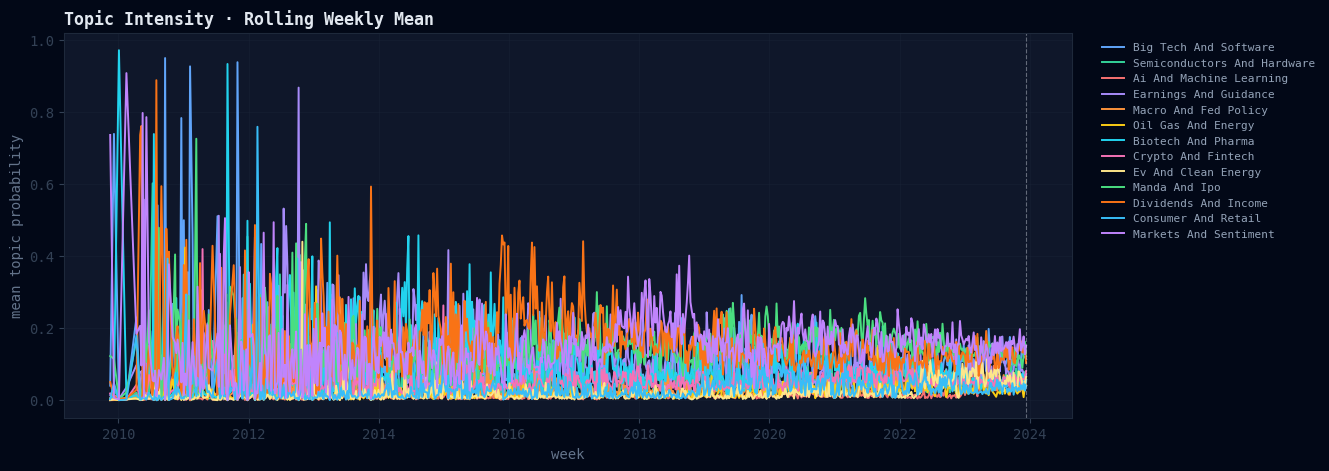

In [4]:
def weekly_intensity(d, topic_cols, date_col="week"):
    return d.groupby(date_col)[topic_cols].mean().sort_index()

wi = weekly_intensity(df, TOPIC_COLS)

fig, ax = plt.subplots(figsize=(13, 5))
for c in TOPIC_COLS:
    ax.plot(wi.index, wi[c], color=TOPIC_COLOR[c], lw=1.4, label=TOPIC_NAMES[c])
ax.axvline(wi.index.max(), color="#e2e8f0", lw=0.8, alpha=0.4, ls="--")
ax.set_title("Topic Intensity · Rolling Weekly Mean", loc="left")
ax.set_xlabel("week"); ax.set_ylabel("mean topic probability")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)
savefig(fig, 2); plt.show()

## 3 · Topic Lifecycle & Phase Detection
Per-topic area chart with gradient fill. Phase is inferred from recent vs prior momentum relative to the topic's peak.

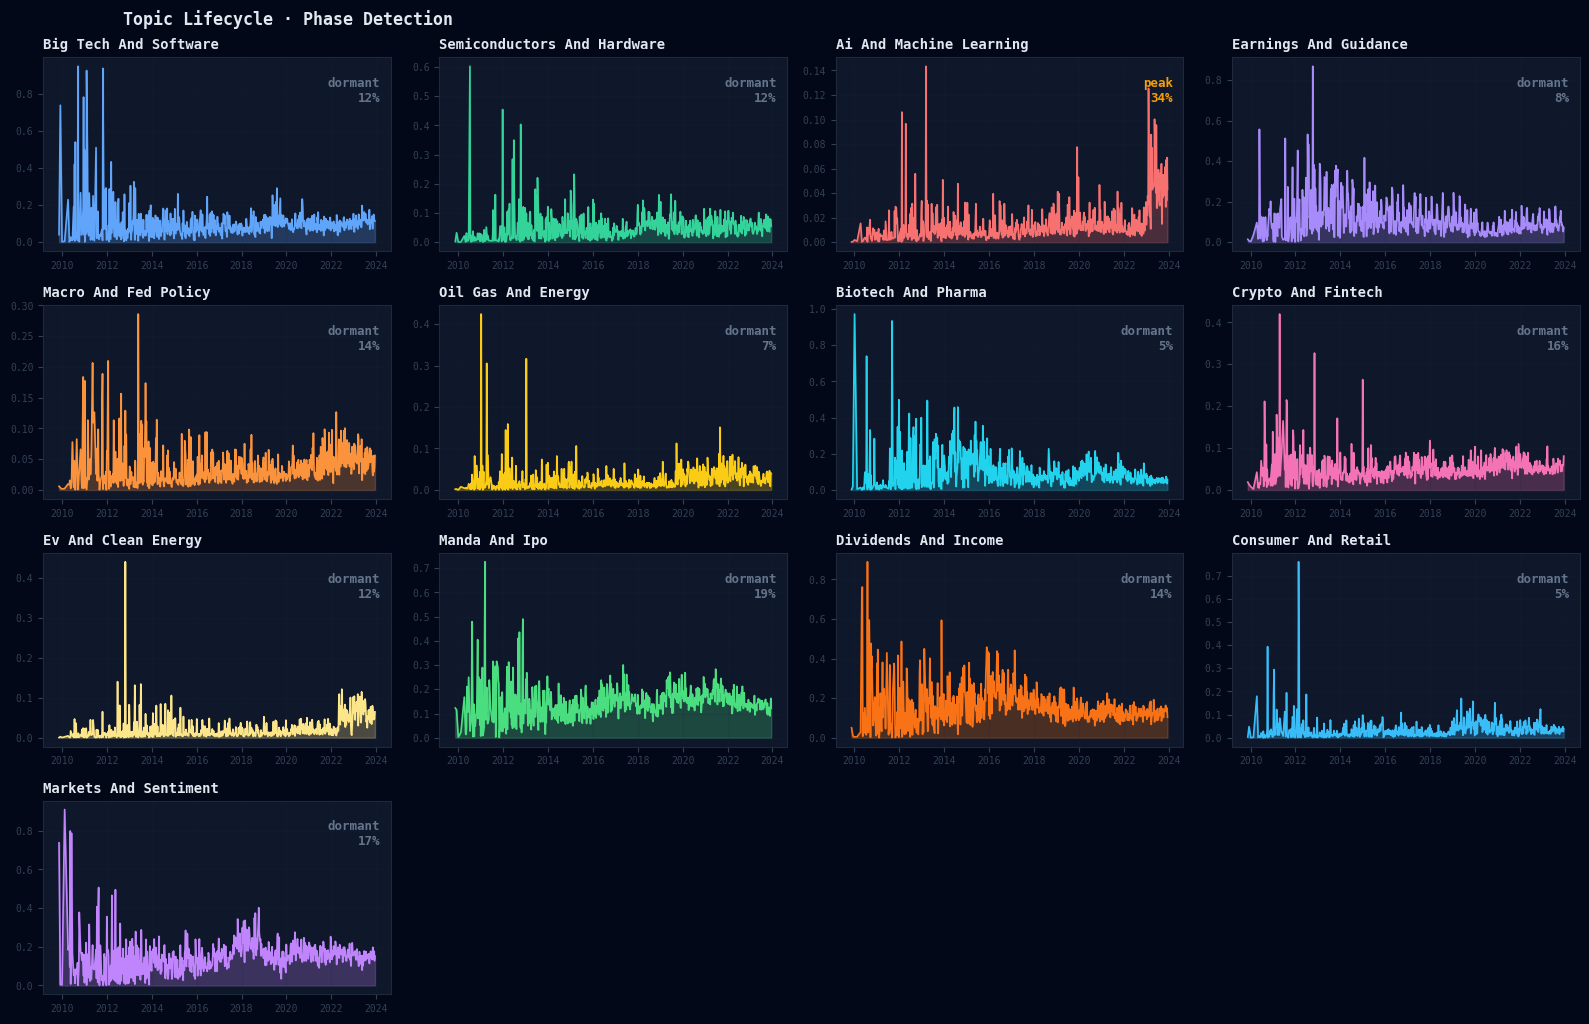

In [5]:
def detect_phase(curve, window=3):
    recent = curve.iloc[-window:].mean()
    prior  = curve.iloc[-2*window:-window].mean()
    peak   = curve.max()
    momentum = recent - prior
    rel = recent / peak if peak > 0 else 0
    if rel < 0.25:        return "dormant", rel
    if momentum > 0.005:  return "rising",  rel
    if momentum < -0.005: return "fading",  rel
    return "peak", rel

def gradient_fill(ax, x, y, color):
    ax.plot(x, y, color=color, lw=1.2)
    ax.fill_between(x, y, color=color, alpha=0.25)

n = len(TOPIC_COLS); ncol = 4; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 2.6*nrow))
for ax, c in zip(axes.flat, TOPIC_COLS):
    s = wi[c]
    gradient_fill(ax, s.index, s.values, TOPIC_COLOR[c])
    phase, rel = detect_phase(s)
    ax.text(0.97, 0.9, f"{phase}\n{rel:.0%}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color=PHASE_COLORS[phase], weight="bold")
    ax.set_title(TOPIC_NAMES[c], loc="left", fontsize=10)
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Topic Lifecycle · Phase Detection", color="#e2e8f0", weight="bold", x=0.08, ha="left")
fig.tight_layout()
savefig(fig, 3); plt.show()

## 4 · Seasonality Heatmap
Mean topic intensity by ISO week — collapses multi-year history into a single seasonal view.

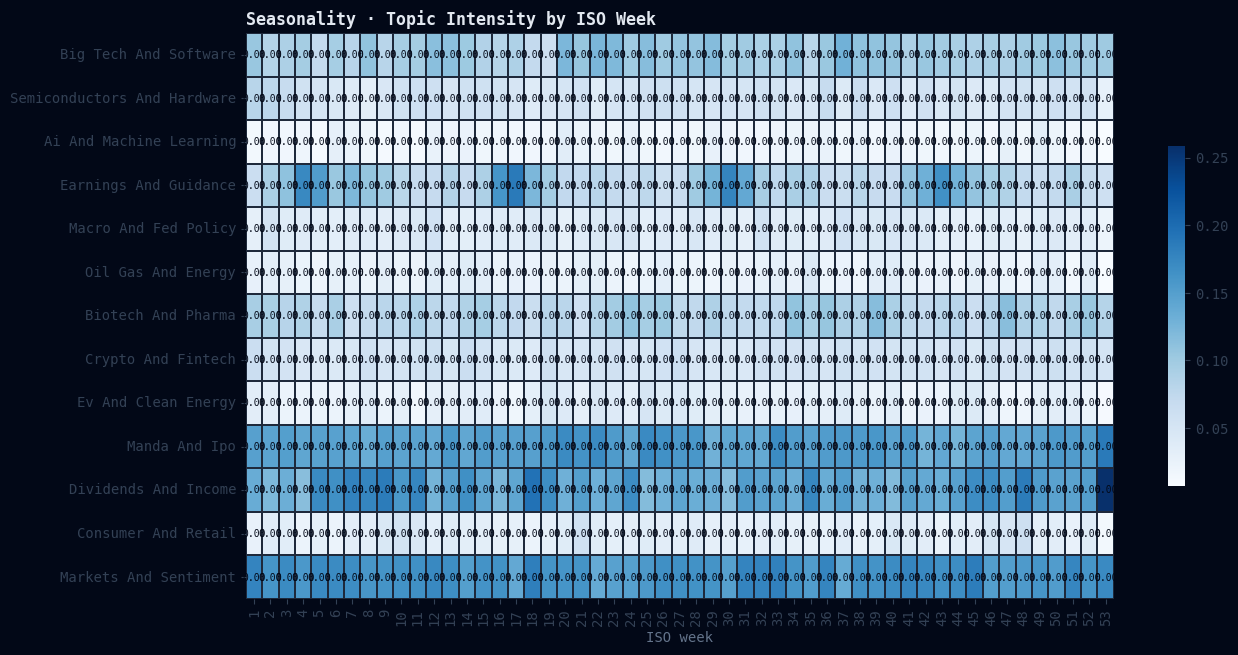

In [6]:
season = df.groupby("iso_week")[TOPIC_COLS].mean().T
season.index = [TOPIC_NAMES[c] for c in season.index]

fig, ax = plt.subplots(figsize=(14, 0.45*len(season)+1.5))
sns.heatmap(season, cmap="Blues", linewidths=0.3, linecolor=BORDER,
            annot=(season > 0.6), fmt=".2f",
            annot_kws={"color":"#020817","size":7}, cbar_kws={"shrink":0.6}, ax=ax)
ax.set_title("Seasonality · Topic Intensity by ISO Week", loc="left")
ax.set_xlabel("ISO week"); ax.set_ylabel("")
savefig(fig, 4); plt.show()

## 5 · Sentiment Trajectory
Per-topic weekly intensity (left axis) vs probability-weighted FinBERT sentiment (right axis).

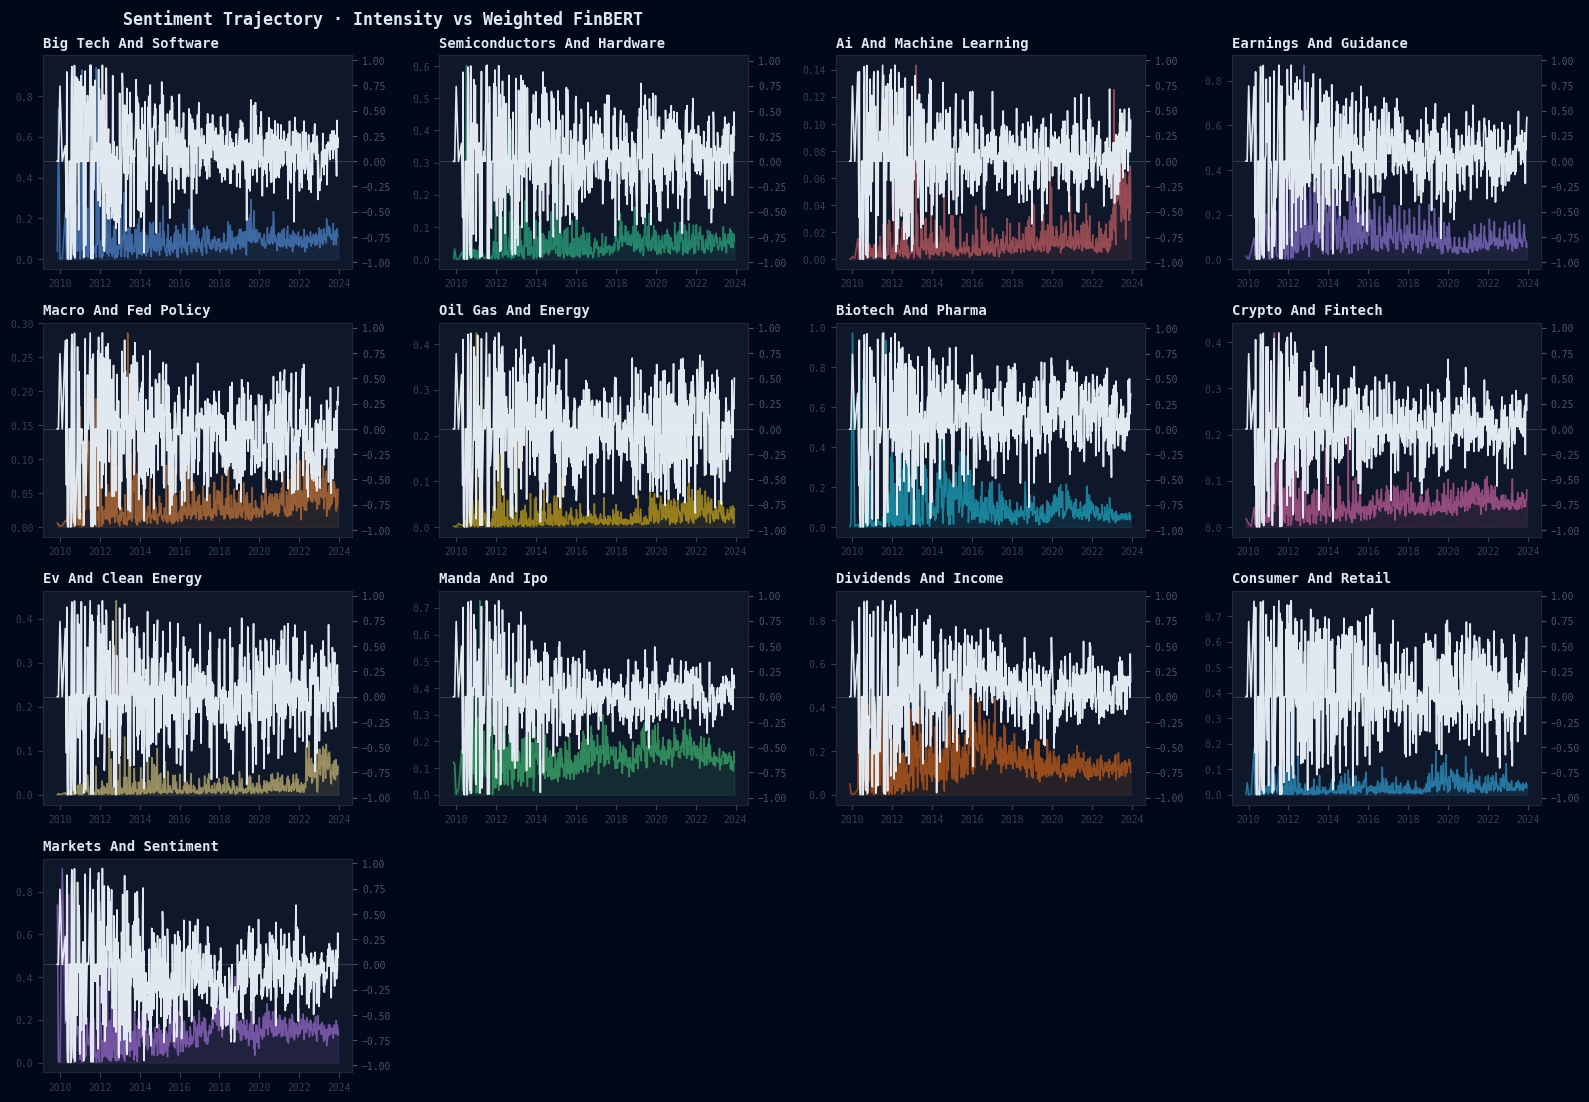

In [7]:
def weighted_sentiment(d, topic_col, date_col="week"):
    num = (d["finbert_score"] * d[topic_col]).groupby(d[date_col]).sum()
    den = d.groupby(date_col)[topic_col].sum()
    return (num / den.replace(0, np.nan)).sort_index()

n = len(TOPIC_COLS); ncol = 4; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 2.8*nrow))
for ax, c in zip(axes.flat, TOPIC_COLS):
    s_i = wi[c]; s_s = weighted_sentiment(df, c)
    ax.plot(s_i.index, s_i.values, color=TOPIC_COLOR[c], lw=1.1, alpha=0.5)
    ax.fill_between(s_i.index, s_i.values, color=TOPIC_COLOR[c], alpha=0.1)
    ax2 = ax.twinx()
    ax2.plot(s_s.index, s_s.values, color="#e2e8f0", lw=1.2)
    ax2.axhline(0, color="white", alpha=0.15, lw=0.8)
    ax2.tick_params(colors="#475569", labelsize=7)
    ax2.set_facecolor(SURFACE)
    ax.set_title(TOPIC_NAMES[c], loc="left", fontsize=10)
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Sentiment Trajectory · Intensity vs Weighted FinBERT", color="#e2e8f0",
             weight="bold", x=0.08, ha="left")
fig.tight_layout()
savefig(fig, 5); plt.show()

## 6 · Sentiment Distribution per Topic
Overlapping KDEs of FinBERT score, weighted by topic probability, with ±0.2 sentiment thresholds.

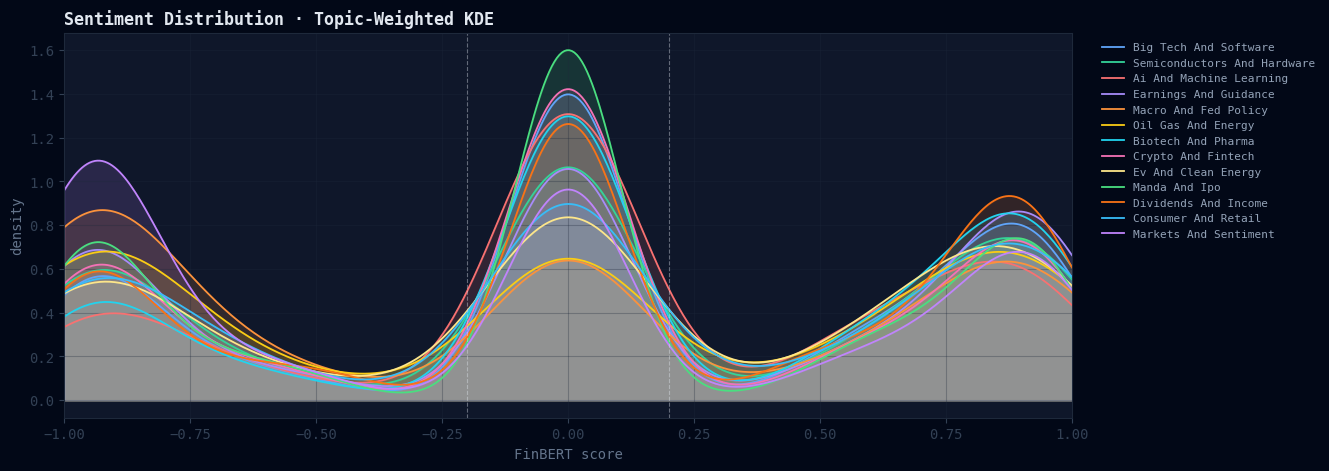

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.linspace(-1, 1, 400)
for c in TOPIC_COLS:
    w = df[c].values
    if w.sum() <= 0: continue
    kde = gaussian_kde(df["finbert_score"].values, weights=w)
    y = kde(x)
    ax.plot(x, y, color=TOPIC_COLOR[c], lw=1.3, label=TOPIC_NAMES[c])
    ax.fill_between(x, y, color=TOPIC_COLOR[c], alpha=0.15)
for v in (-0.2, 0.2):
    ax.axvline(v, color="#e2e8f0", ls="--", lw=0.8, alpha=0.4)
ax.set_xlim(-1, 1)
ax.set_title("Sentiment Distribution · Topic-Weighted KDE", loc="left")
ax.set_xlabel("FinBERT score"); ax.set_ylabel("density")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)
savefig(fig, 6); plt.show()

## 7 · Embedding Space (UMAP)
UMAP projection of the 768-d FinBERT embeddings, coloured by dominant topic and by sentiment.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


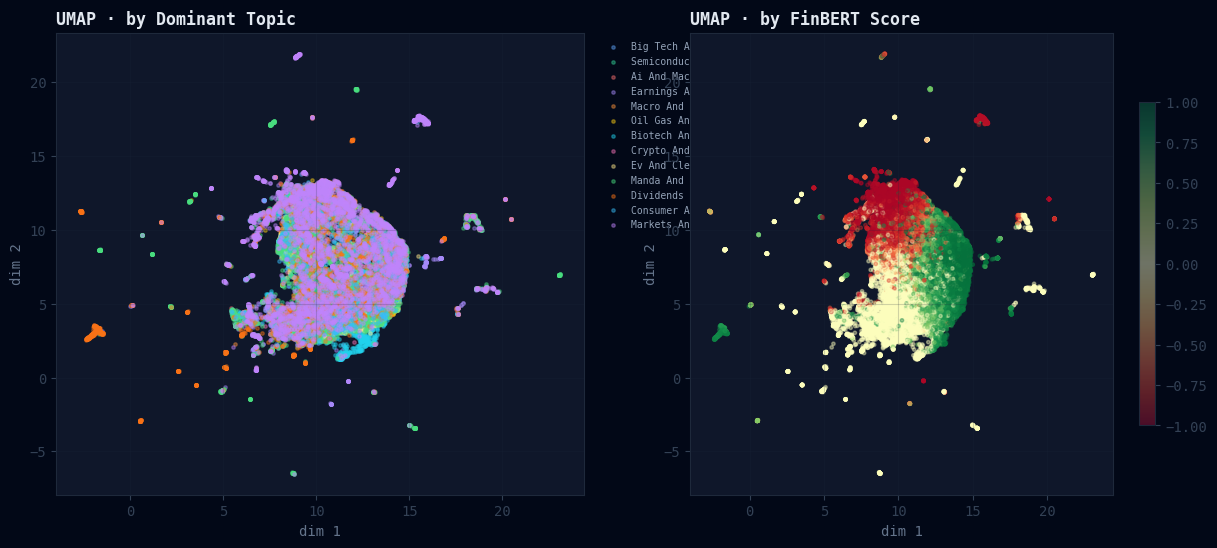

In [9]:
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    coords = reducer.fit_transform(df_sentiment[EMB_COLS].values)
    use_label = "UMAP"
except Exception as e:
    print(f"UMAP unavailable ({e}); falling back to PCA-2D")
    coords = PCA(n_components=2, random_state=42).fit_transform(df_sentiment[EMB_COLS].values)
    use_label = "PCA"

emb_df = df_sentiment[["article_id"]].copy()
emb_df["x"], emb_df["y"] = coords[:, 0], coords[:, 1]
emb_df = emb_df.merge(df[["article_id","finbert_score"] + TOPIC_COLS], on="article_id")
emb_df["dom_topic"] = emb_df[TOPIC_COLS].idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for c in TOPIC_COLS:
    m = emb_df["dom_topic"] == c
    axes[0].scatter(emb_df.loc[m, "x"], emb_df.loc[m, "y"],
                    s=6, alpha=0.4, color=TOPIC_COLOR[c], label=TOPIC_NAMES[c])
axes[0].set_title(f"{use_label} · by Dominant Topic", loc="left")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=7)

sc = axes[1].scatter(emb_df["x"], emb_df["y"], c=emb_df["finbert_score"],
                     cmap="RdYlGn", vmin=-1, vmax=1, s=6, alpha=0.4)
axes[1].set_title(f"{use_label} · by FinBERT Score", loc="left")
cb = fig.colorbar(sc, ax=axes[1], shrink=0.7); cb.outline.set_edgecolor(BORDER)
for ax in axes: ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); ax.grid(True, alpha=0.2)
savefig(fig, 7); plt.show()

## 8 · 3D Embedding Scatter (PCA)
Top-3 principal components of the embedding space. Colour by dominant topic; axes annotated with explained variance.

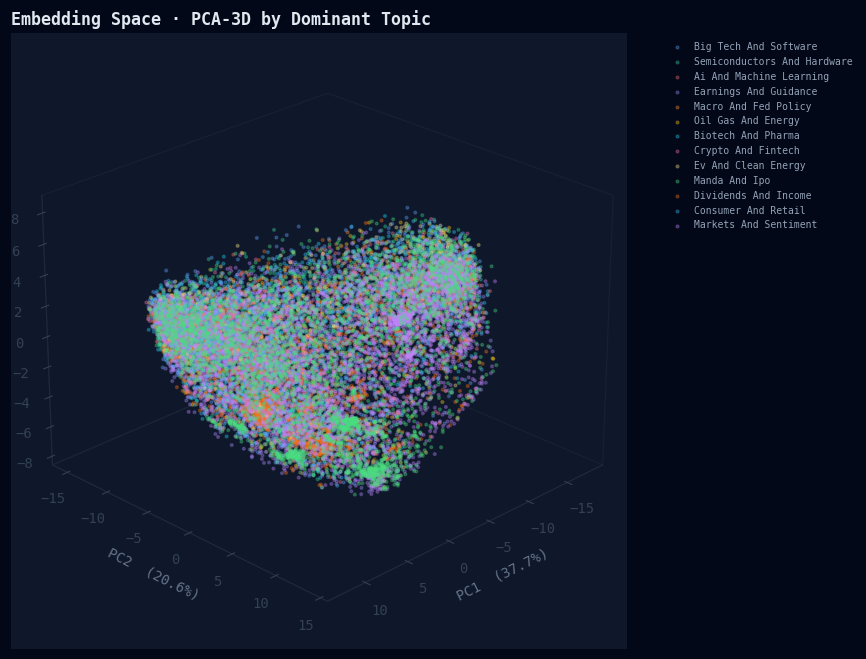

In [10]:
pca = PCA(n_components=3, random_state=42).fit(df_sentiment[EMB_COLS].values)
pts = pca.transform(df_sentiment[EMB_COLS].values)
var = pca.explained_variance_ratio_ * 100

pts_df = df_sentiment[["article_id"]].copy()
pts_df[["p1","p2","p3"]] = pts
pts_df = pts_df.merge(df[["article_id"] + TOPIC_COLS], on="article_id")
pts_df["dom_topic"] = pts_df[TOPIC_COLS].idxmax(axis=1)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor(SURFACE)
for c in TOPIC_COLS:
    m = pts_df["dom_topic"] == c
    ax.scatter(pts_df.loc[m,"p1"], pts_df.loc[m,"p2"], pts_df.loc[m,"p3"],
               s=4, alpha=0.3, color=TOPIC_COLOR[c], label=TOPIC_NAMES[c])
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.fill = False; pane.set_edgecolor(BORDER)
ax.grid(False)
ax.view_init(elev=25, azim=45)
ax.set_xlabel(f"PC1  ({var[0]:.1f}%)"); ax.set_ylabel(f"PC2  ({var[1]:.1f}%)")
ax.set_zlabel(f"PC3  ({var[2]:.1f}%)")
ax.set_title("Embedding Space · PCA-3D by Dominant Topic", loc="left")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=7)
savefig(fig, 8); plt.show()

## 9 · Cross-Topic Correlation
Pearson correlation of weekly topic intensities — reveals topics that spike together.

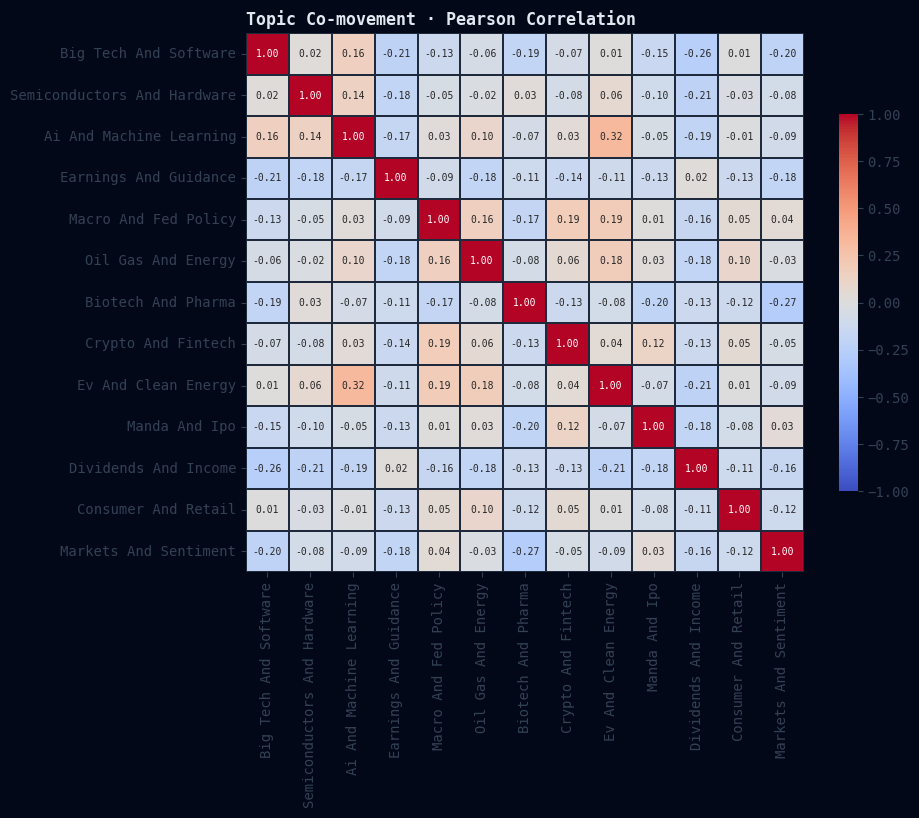

In [11]:
corr = wi.rename(columns=TOPIC_NAMES).corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, linecolor=BORDER, cbar_kws={"shrink":0.7},
            annot_kws={"size":7}, ax=ax)
ax.set_title("Topic Co-movement · Pearson Correlation", loc="left")
savefig(fig, 9); plt.show()

## 10 · Volume vs Intensity per Topic
Bars: count of articles where topic prob > 0.4. Line: mean topic probability. Separates crowd-driven spikes from high-conviction ones.

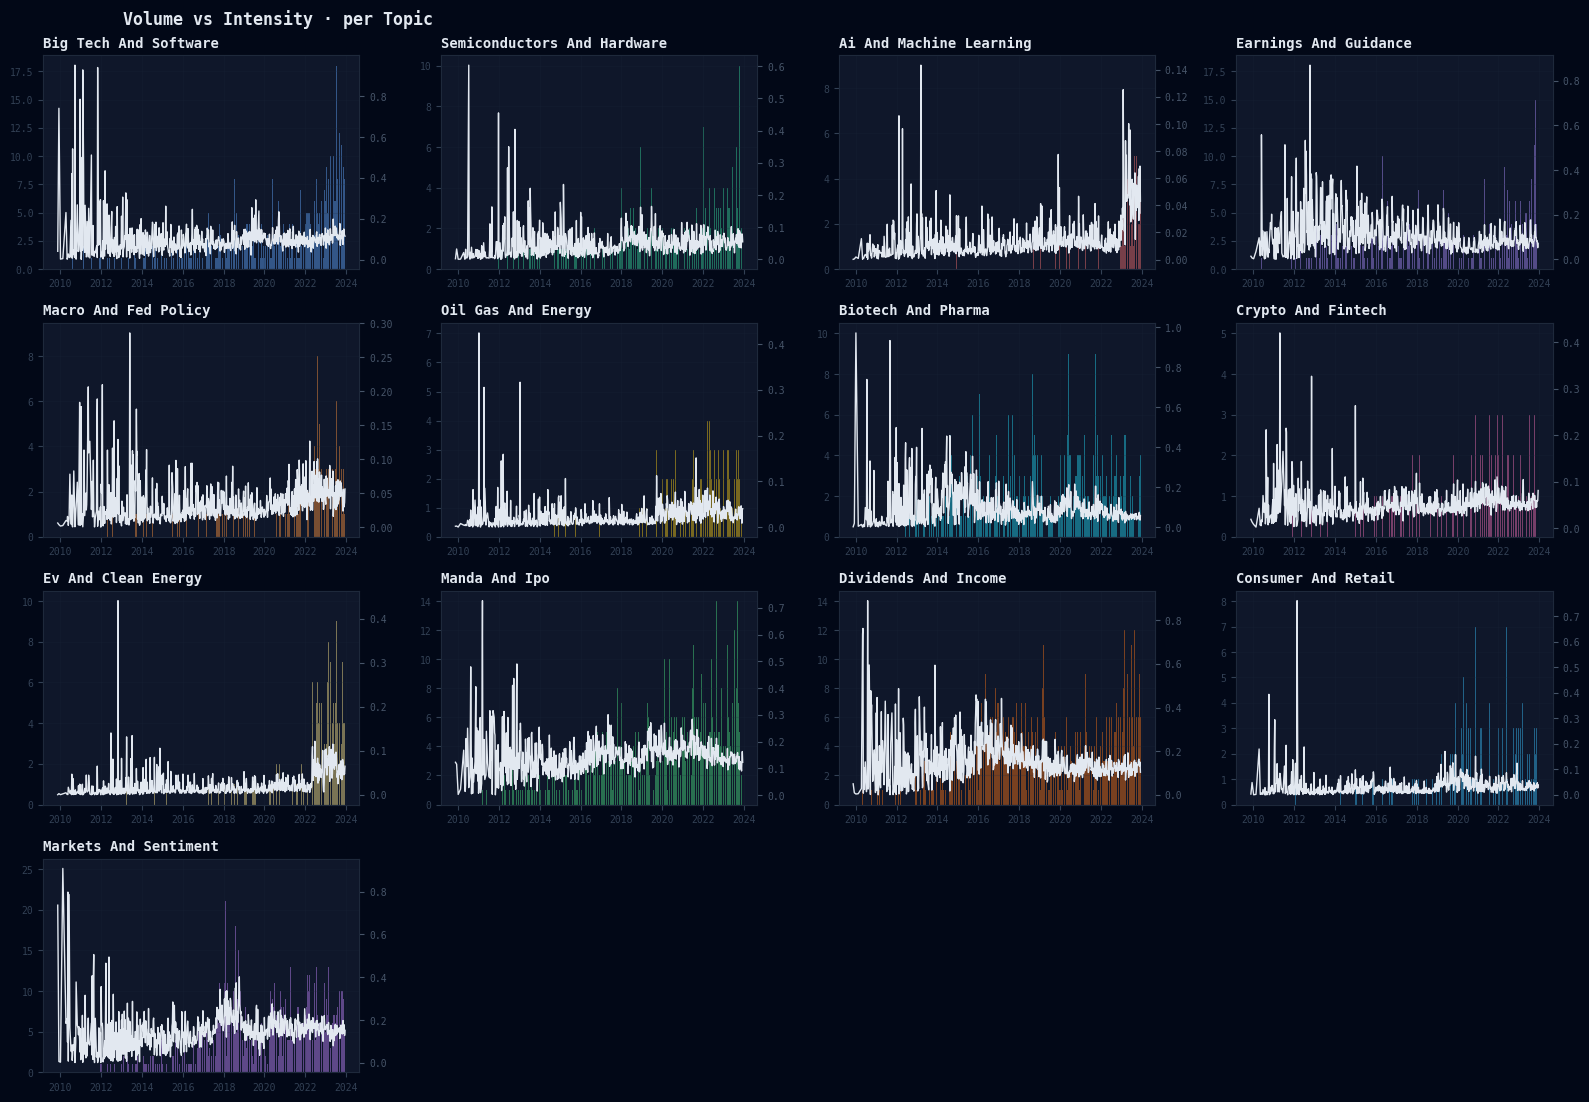

In [12]:
def volume_vs_intensity(d, topic_col, threshold=0.4, date_col="week"):
    active = (d[topic_col] > threshold).astype(int)
    vol = active.groupby(d[date_col]).sum()
    intensity = d.groupby(date_col)[topic_col].mean()
    return vol.sort_index(), intensity.sort_index()

n = len(TOPIC_COLS); ncol = 4; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 2.8*nrow))
for ax, c in zip(axes.flat, TOPIC_COLS):
    vol, inten = volume_vs_intensity(df, c)
    ax.bar(vol.index, vol.values, width=5, color=TOPIC_COLOR[c], alpha=0.45,
           edgecolor="none")
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)
    ax2 = ax.twinx()
    ax2.plot(inten.index, inten.values, color="#e2e8f0", lw=1.0)
    ax2.set_facecolor(SURFACE); ax2.tick_params(colors="#475569", labelsize=7)
    ax.set_title(TOPIC_NAMES[c], loc="left", fontsize=10)
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Volume vs Intensity · per Topic", color="#e2e8f0",
             weight="bold", x=0.08, ha="left")
fig.tight_layout()
savefig(fig, 10); plt.show()

## 11 · Ticker Co-mention Network
The corpus has one ticker per article, so we build co-mentions from tickers sharing publication day + source.
Nodes sized by degree centrality, coloured by the ticker's most-frequent dominant topic.

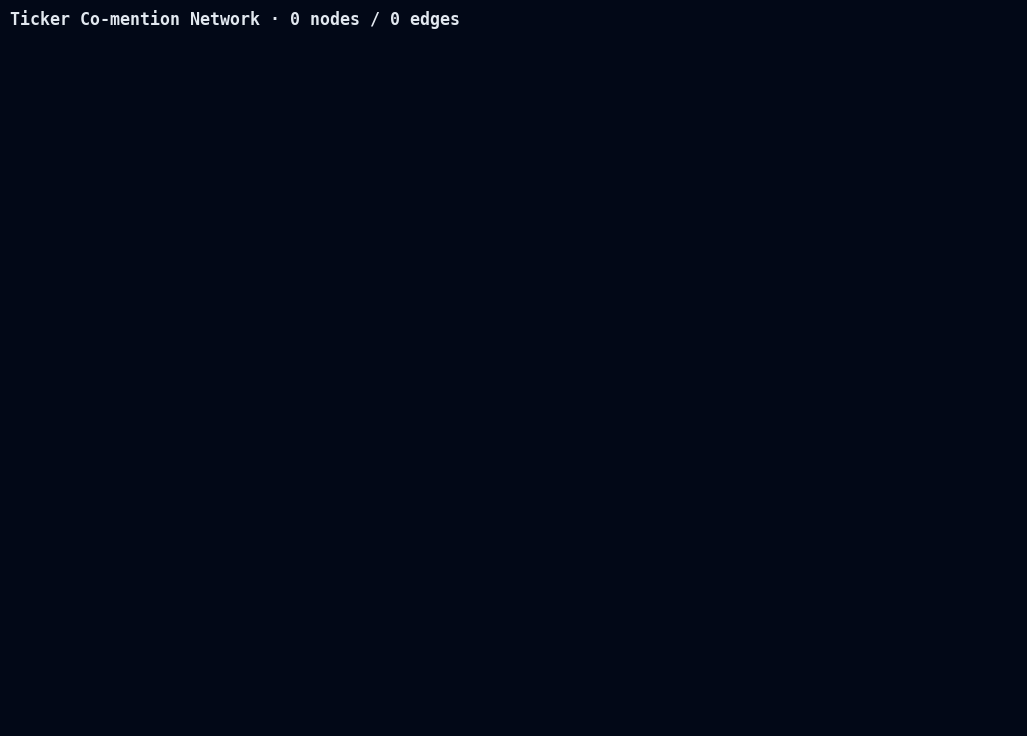

In [13]:
from itertools import combinations
try:
    import networkx as nx
except Exception:
    nx = None

if nx is None or "ticker" not in df.columns:
    print("networkx unavailable or no ticker column — skipping.")
else:
    tmp = df[["article_id","ticker","source","published_date"] + TOPIC_COLS].dropna(subset=["ticker"]).copy()
    tmp["dom_topic"] = tmp[TOPIC_COLS].idxmax(axis=1)
    # co-mentions: same source, same day
    groups = tmp.groupby([tmp["published_date"].dt.date, "source"])["ticker"].apply(lambda s: list(set(s)))
    G = nx.Graph()
    for tickers in groups:
        if len(tickers) < 2: continue
        for a, b in combinations(sorted(tickers), 2):
            if G.has_edge(a, b): G[a][b]["weight"] += 1
            else: G.add_edge(a, b, weight=1)
    # prune to top edges by weight to keep plot readable
    if G.number_of_edges() > 300:
        edges = sorted(G.edges(data=True), key=lambda e: -e[2]["weight"])[:300]
        G = nx.Graph(); G.add_edges_from((u,v,d) for u,v,d in edges)

    dom = tmp.groupby("ticker")["dom_topic"].agg(lambda s: s.mode().iat[0]).to_dict()
    deg = dict(G.degree())
    pos = nx.spring_layout(G, seed=42, k=0.8)
    sizes  = [30 + 15*deg[n] for n in G.nodes()]
    colors = [TOPIC_COLOR.get(dom.get(n), "#64748b") for n in G.nodes()]
    wmax   = max((d["weight"] for _,_,d in G.edges(data=True)), default=1)
    widths = [1 + 3*(d["weight"]/wmax) for _,_,d in G.edges(data=True)]

    fig, ax = plt.subplots(figsize=(13, 9))
    ax.set_facecolor(BG)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color=BORDER, alpha=0.6, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors,
                           edgecolors=BG, linewidths=0.5, ax=ax)
    top = sorted(deg, key=deg.get, reverse=True)[:25]
    nx.draw_networkx_labels(G, pos, {n:n for n in top}, font_size=7,
                            font_color="#e2e8f0", ax=ax)
    ax.set_title(f"Ticker Co-mention Network · {G.number_of_nodes()} nodes / {G.number_of_edges()} edges",
                 loc="left")
    ax.axis("off")
    savefig(fig, 11); plt.show()

## 12 · Narrative Pressure · hero chart
Composite per-topic score blending level, positive momentum, and positive sentiment — stacked over time.

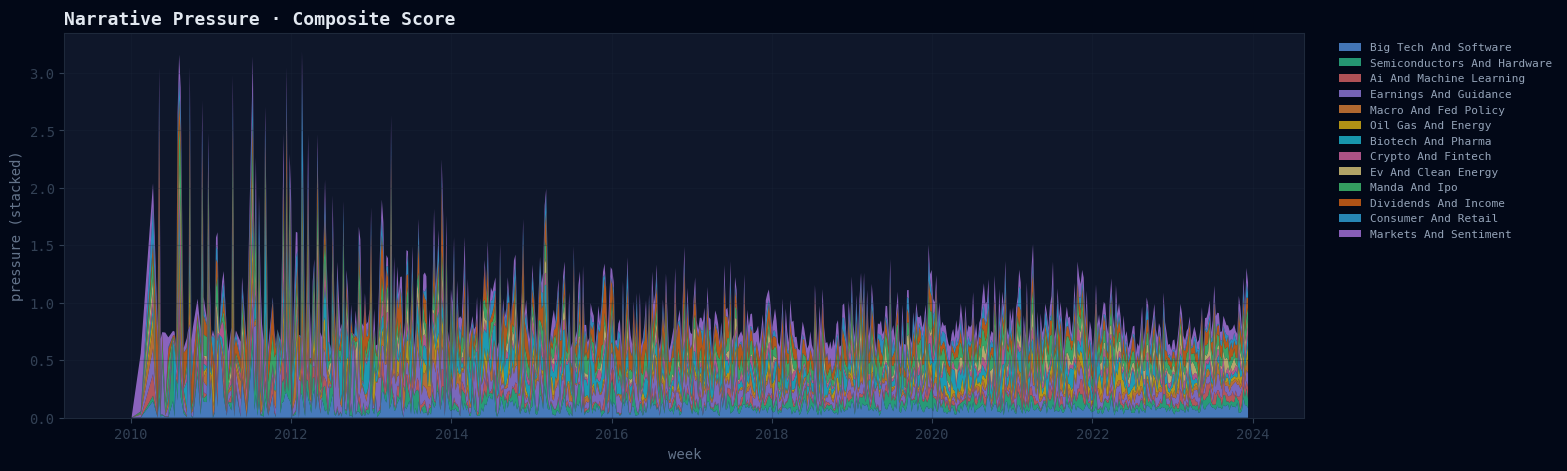

In [14]:
def narrative_pressure(intensity, sentiment, window=3):
    momentum = intensity.diff(window)
    score = 0.5*intensity + 0.3*momentum.clip(lower=0) + 0.2*sentiment.clip(lower=0)
    return score.clip(0, 1)

pressure = pd.DataFrame(index=wi.index)
for c in TOPIC_COLS:
    pressure[c] = narrative_pressure(wi[c], weighted_sentiment(df, c).reindex(wi.index)).fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
ax.stackplot(pressure.index, [pressure[c] for c in TOPIC_COLS],
             labels=[TOPIC_NAMES[c] for c in TOPIC_COLS],
             colors=[TOPIC_COLOR[c] for c in TOPIC_COLS], alpha=0.7)
ax.set_title("Narrative Pressure · Composite Score", loc="left", fontsize=13)
ax.set_xlabel("week"); ax.set_ylabel("pressure (stacked)")
ax.grid(True, alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8, ncol=1)
savefig(fig, 12); plt.show()